In [2]:
import keras
from keras import layers
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from metrics_tracking import F1Score, plot_metrics

In [3]:
OTIDS_file_colab = "OTIDS_clean_data.npz"
OTIDS_file_local = "Preprocessed_Data/OTIDS_clean_data.npz"
data = np.load(OTIDS_file_local)
# Access arrays by the names you used when saving
X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
y_train = y_train.astype("int32").ravel()
y_test  = y_test.astype("int32").ravel()

In [48]:
def create_model_otids():
    inp = keras.Input(shape=(600, 11))
    x = layers.Conv1D(64, 12, activation='relu')(inp)
    x_max = layers.GlobalMaxPooling1D()(x)
    x_avg = layers.GlobalAveragePooling1D()(x)
    x = layers.Concatenate()([x_max, x_avg])
    x = layers.Dense(32, activation='relu')(x)   # optional small dense
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    return model
model = create_model_otids()
#1d cnn sequential model:
# def create_model_otids(num_filters=128, kernel=8): #this is the same model we'll always use for all.
#     model = keras.Sequential()
#     model.add(layers.Input(shape=(600, 11)))
#     #model.add(layers.Conv1D(128, 8, activation='relu'))#64 was pretty decent
#     model.add(layers.Conv1D(num_filters, 8, activation='relu'))
#     # model.add(layers.GlobalMaxPooling1D())
#     model.add(layers.GlobalAveragePooling1D())
#     model.add(layers.Dense(1, activation='sigmoid')) #output 1 bc we only have 2 labels: attack or not attack
#     return model

# filters = 96 #128
# kernel_size = 16 #8
# model = create_model_otids(96, 16)

In [49]:
callbacks = [
    ModelCheckpoint("saved_models/best_model_OTIDS_128cnn.keras", monitor='val_auc', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-12, verbose=1),
    EarlyStopping(monitor='val_auc', patience=10, verbose=1, restore_best_weights=True)
]
model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss="binary_crossentropy",   # correct for sigmoid + 0/1 labels
    metrics=[
        keras.metrics.AUC(name="auc"),
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        F1Score(name="f1")
    ]
)
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=70,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/70
954/957 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5259 - auc: 0.5270 - f1: 0.5857 - loss: 0.6920 - precision: 0.5294 - recall: 0.6570
Epoch 1: val_auc improved from None to 0.76702, saving model to saved_models/best_model_OTIDS_128cnn.keras
957/957 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.5415 - auc: 0.5605 - f1: 0.6050 - loss: 0.6870 - precision: 0.5424 - recall: 0.6841 - val_accuracy: 0.5850 - val_auc: 0.7670 - val_f1: 0.3651 - val_loss: 0.6752 - val_precision: 0.8694 - val_recall: 0.2311 - learning_rate: 5.0000e-04
Epoch 2/70
955/957 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6126 - auc: 0.6672 - f1: 0.6346 - loss: 0.6605 - precision: 0.6126 - recall: 0.6671
Epoch 2: val_auc improved from 0.76702 to 0.80386, saving model to saved_models/best_model_OTIDS_128cnn.keras
957/957 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.6416 - auc: 0.6981 - f1: 0.6667 - loss: 0.6445 - precision: 0.6378 - recall: 0.6982 - val_accuracy: 0.7125 - val_auc: 0.8039 - val_f1

In [52]:
testing_acc = model.evaluate(X_test,y_test, verbose=1)
print(f"Test loss: {testing_acc[0]}")
print(f"Test accuracy: {testing_acc[1]}")
print(f"Test AUC: {testing_acc[2]}")
print(f"Test Precision: {testing_acc[3]}")
print(f"Test Recall: {testing_acc[4]}")
print(f"Test F1: {testing_acc[5]}")

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7996 - auc: 0.8774 - f1: 0.8025 - loss: 0.4978 - precision: 0.8127 - recall: 0.7926
Test loss: 0.4978492856025696
Test accuracy: 0.8773990869522095
Test AUC: 0.7996237277984619
Test Precision: 0.8126760721206665
Test Recall: 0.7925823926925659
Test F1: 0.8025034666061401


In [53]:
model.save("best_OTIDS_model128.keras")

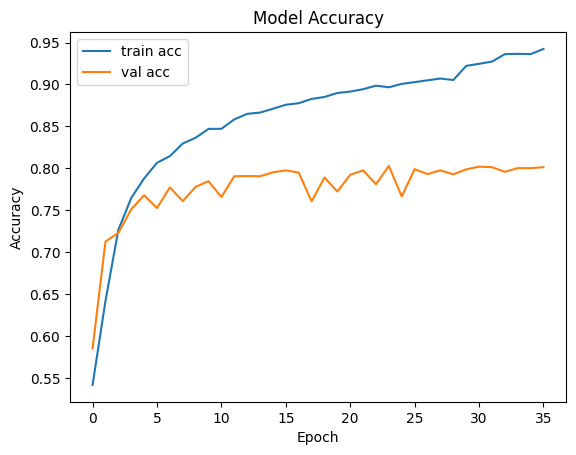

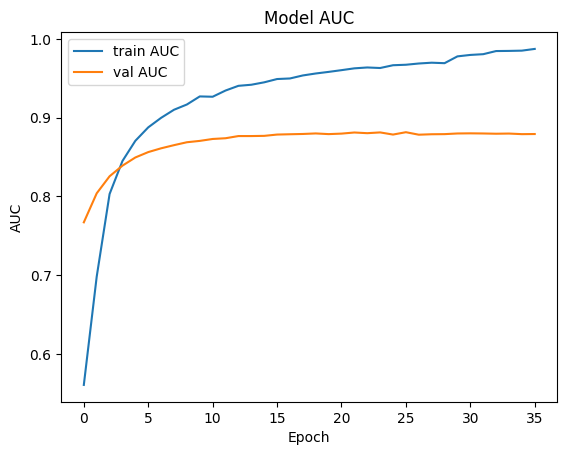

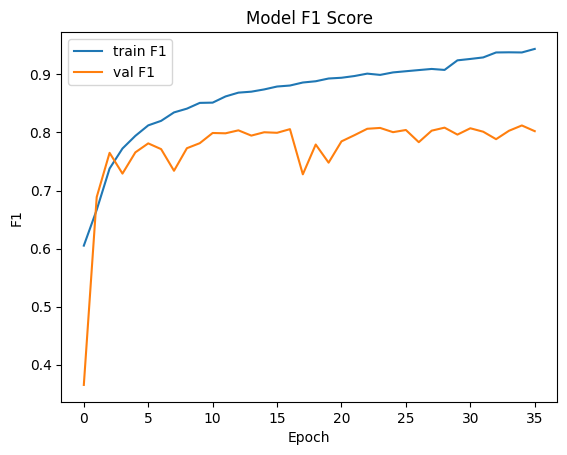

In [54]:
plot_metrics(history)

In [55]:
y_pred_probs = model.predict(X_test).ravel()     # shape: (N,)
y_pred = (y_pred_probs >= 0.5).astype(int)       # threshold

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred, target_names=["Ambient", "Attack"]))

# --- Correct ROC-AUC for binary classifier ---
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

     Ambient       0.79      0.81      0.80      4136
      Attack       0.81      0.79      0.80      4368

    accuracy                           0.80      8504
   macro avg       0.80      0.80      0.80      8504
weighted avg       0.80      0.80      0.80      8504

ROC AUC Score: 0.8777


In [ ]:
# def standardize(X_train, y_train, X_test, y_test):
#     # Step 1: Clip outliers (important for ROAD)
#     X_train = np.clip(X_train, -1e6, 1e6)
#     X_test  = np.clip(X_test,  -1e6, 1e6)
#     # Step 2: Standardize features
#     scaler = StandardScaler()
#     X_train_flat = X_train.reshape(-1, X_train.shape[-1])
#     X_test_flat  = X_test.reshape(-1,  X_test.shape[-1])
#     X_train_scaled = scaler.fit_transform(X_train_flat)
#     X_test_scaled  = scaler.transform(X_test_flat)
#     X_train = X_train_scaled.reshape(X_train.shape)
#     X_test  = X_test_scaled.reshape(X_test.shape)
#     return X_train, y_train, X_test, y_test
# X_train, y_train, X_test, y_test = standardize(X_train, y_train, X_test, y_test)

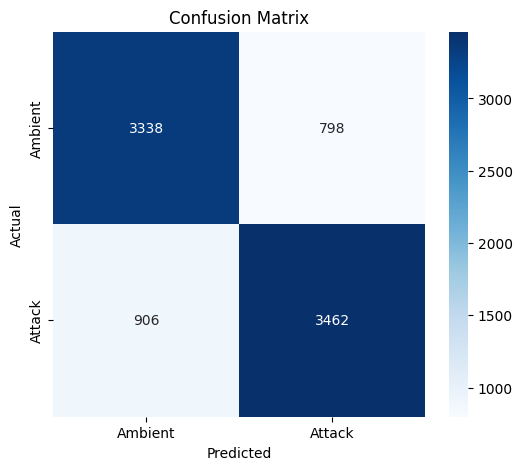

In [56]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Ambient", "Attack"],
    yticklabels=["Ambient", "Attack"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#current matrix above is for OTIDS_128 kernel size